# Exam Project

Import and set magics:

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from types import SimpleNamespace

from problem1_analysis import DanishHousePrices
from ExchangeEconomyModel import (
    ExchangeEconomyModelClass,
    tatonnement,
    newton_raphson_dampened,
    find_unique_equilibria,
    plot_demand_and_excess_demand,
    plot_tatonnement_convergence,
    plot_basin_of_attraction,
    plot_edgeworth_box_equilibria
)
from ASADModel import ASADModelClass

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

## 1. Danish House Prices

In [3]:
analyzer = DanishHousePrices()

### Question 1.1

In [4]:
prices = analyzer.fetch_house_prices()

In [5]:
# Inspect the data structure
print(f"Data shape: {prices.shape}")
print(f"Time period: {prices.index[0]} to {prices.index[-1]}")
print(f"\nFirst few rows:")
prices.head()

Data shape: (135, 16)
Time period: 1992-01-01 00:00:00 to 2025-07-01 00:00:00

First few rows:


OMRÅDE,All Denmark,Province Byen København,Province Fyn,Province Københavns omegn,Province Nordjylland,Province Nordsjælland,Province Sydjylland,Province Vest- og Sydsjælland,Province Vestjylland,Province Østjylland,Province Østsjælland,Region Hovedstaden,Region Midtjylland,Region Nordjylland,Region Sjælland,Region Syddanmark
time,,,,,,,,,,,,,,,,
1992-01-01,100.000000,100.0,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
1992-04-01,100.000000,101.6,101.086957,98.701299,100.589971,99.473684,99.706745,100.000000,99.50,100.000000,100.000000,100.000000,100.000000,100.589971,100.000000,100.000000
1992-07-01,97.959184,101.6,98.913043,96.103896,97.345133,96.842105,99.120235,97.419355,97.25,100.000000,98.048780,97.546012,98.947368,97.345133,97.735849,99.038462
1992-10-01,95.510204,96.0,96.739130,94.805195,96.460177,93.684211,97.067449,94.516129,95.75,96.296296,94.634146,94.478528,96.140351,96.460177,94.716981,96.794872
1993-01-01,94.285714,96.0,97.101449,92.857143,94.100295,92.631579,95.601173,93.548387,94.50,94.238683,93.170732,93.251534,94.385965,94.100295,93.584906,96.153846


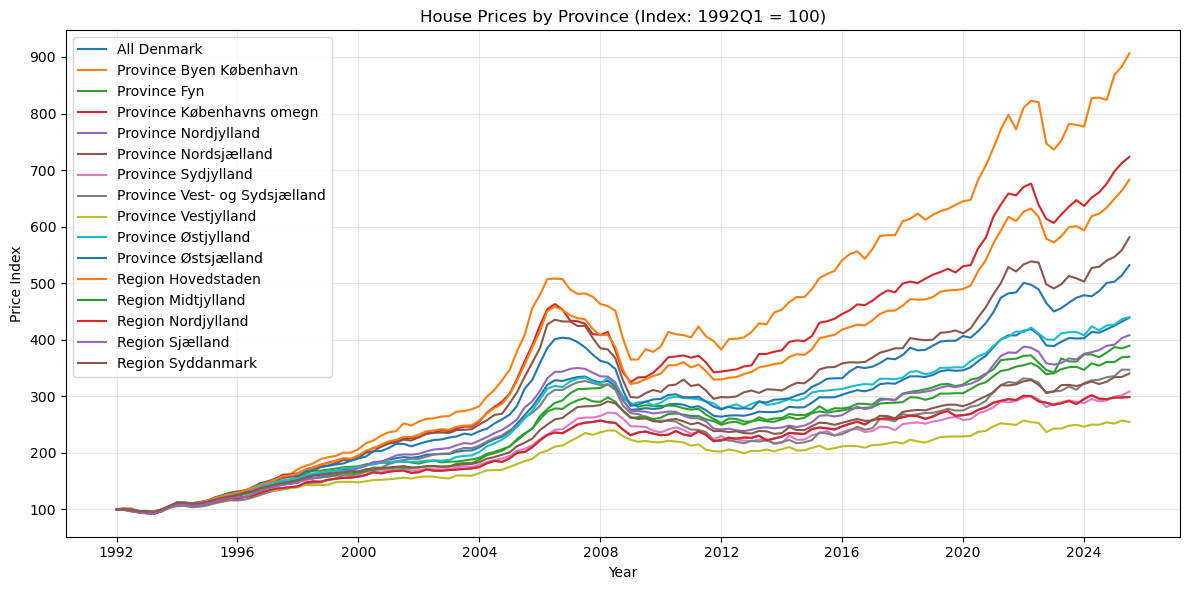

In [6]:
analyzer.plot_nominal_prices();

In [7]:
# Calculate summary statistics for price growth
price_growth = prices.iloc[-1] - prices.iloc[0]
print("Price growth by region (index points):")
print(price_growth.sort_values(ascending=False))
print(f"\nMean growth: {price_growth.mean():.2f}")
print(f"Std deviation: {price_growth.std():.2f}")

Price growth by region (index points):
OMRÅDE
Province Byen København          806.400000
Province Københavns omegn        623.376623
Region Hovedstaden               582.822086
Province Nordsjælland            481.052632
Province Østsjælland             431.707317
Province Østjylland              339.917695
All Denmark                      338.775510
Region Sjælland                  307.924528
Province Fyn                     289.130435
Region Midtjylland               269.824561
Province Vest- og Sydsjælland    246.774194
Region Syddanmark                240.064103
Province Sydjylland              208.211144
Province Nordjylland             198.525074
Region Nordjylland               198.525074
Province Vestjylland             154.500000
dtype: float64

Mean growth: 357.35
Std deviation: 182.45


The plot shows significant regional variation in nominal house price development since 1992. Copenhagen region shows the strongest growth, with prices increasing by over 300 index points. Regions like North Jutland and Bornholm show more modest growth. The 2008 financial crisis is visible as a sharp downturn across all regions, with recovery beginning around 2012-2013.

### Question 1.2

In [8]:
cpi = analyzer.fetch_cpi()

In [9]:
real = analyzer.calculate_real_prices()

In [10]:
# Compare nominal vs real growth for Copenhagen
copenhagen_nominal = prices['Province Byen København'].iloc[-1] - prices['Province Byen København'].iloc[0]
copenhagen_real = real['Province Byen København'].iloc[-1] - real['Province Byen København'].iloc[0]

print(f"Copenhagen growth:")
print(f"  Nominal: {copenhagen_nominal:.2f} index points")
print(f"  Real: {copenhagen_real:.2f} index points")
print(f"  Inflation effect: {copenhagen_nominal - copenhagen_real:.2f} index points")

Copenhagen growth:
  Nominal: 806.40 index points
  Real: 380.29 index points
  Inflation effect: 426.11 index points


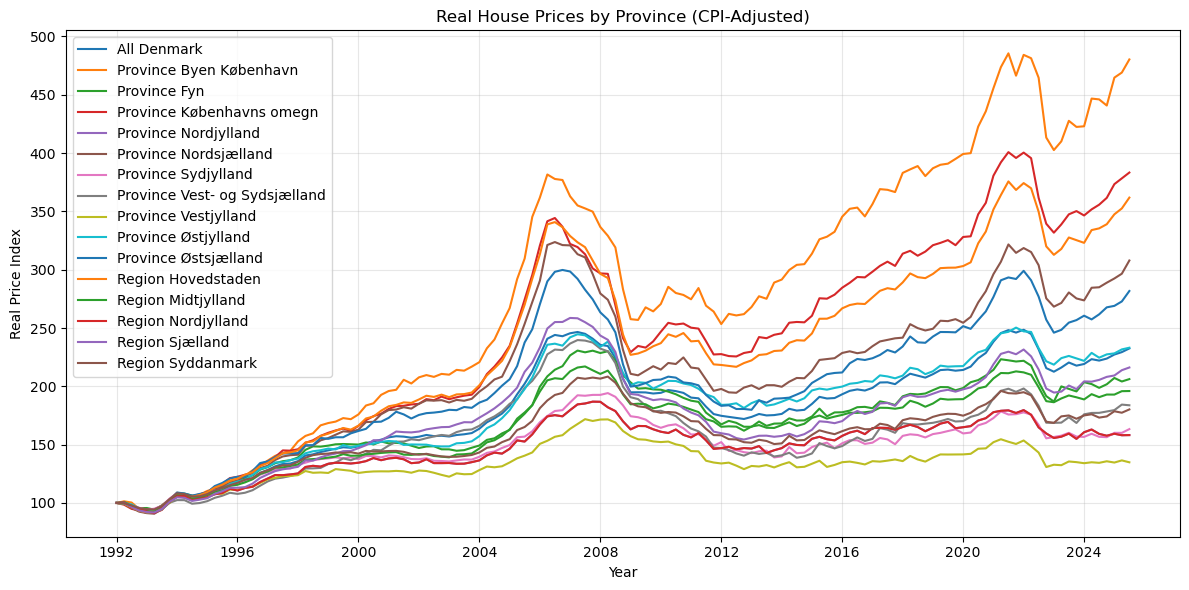

In [11]:
analyzer.plot_real_prices();

When adjusting for inflation, the real price growth is significantly lower than nominal growth. This shows that a substantial part of the nominal price increases simply reflects general inflation in the economy. The crisis impact appears more severe in real terms, with some regions experiencing prolonged periods below their pre-crisis real price levels. This indicates that housing has not universally been a strong inflation hedge in Denmark.

In [12]:
rankings = analyzer.rank_provinces()
rankings

OMRÅDE
Province Byen København          380.286663
Province Københavns omegn        283.305543
Region Hovedstaden               261.816352
Province Nordsjælland            207.890368
Province Østsjælland             181.743086
Province Østjylland              133.105254
All Denmark                      132.500028
Region Sjælland                  116.152593
Province Fyn                     106.193908
Region Midtjylland                95.964038
Province Vest- og Sydsjælland     83.750022
Region Syddanmark                 80.194454
Province Sydjylland               63.316087
Province Nordjylland              58.183596
Region Nordjylland                58.183596
Province Vestjylland              34.855423
dtype: float64

The ranking confirms Copenhagen as the strongest performing region, followed by other urban centers. The geographic pattern suggests that urbanization and economic centralization have been key drivers of house price growth in Denmark over this period.

### Question 1.3

Load data from BM010_houses.xlsx and analyze growth vs initial price levels

In [13]:
muni_data = analyzer.load_municipality_data('BM010_houses.xlsx')

In [14]:
# Explore municipality data
print(f"Number of municipalities: {len(muni_data)}")
print(f"Number of quarters: {len(muni_data.columns) - 1}")
print(f"\nSample data:")
muni_data.head()

Number of municipalities: 92
Number of quarters: 134

Sample data:


,Municipality,1992Q1,1992Q2,1992Q3,1992Q4,1993Q1,1993Q2,1993Q3,1993Q4,1994Q1,...,2023Q1,2023Q2,2023Q3,2023Q4,2024Q1,2024Q2,2024Q3,2024Q4,2025Q1,2025Q2
0,København,5355.0,5451.0,5374.0,5171.0,5068.0,5186.0,5609.0,5519.0,5503.0,...,43538.0,46023.0,47651,48146.0,47769.0,51843,52011,54143.0,56588.0,56744.0
2,Dragør,6251.0,6472.0,6364.0,6246.0,6158.0,6438.0,6573.0,6261.0,5969.0,...,33809.0,33105.0,35803,33492.0,34092.0,35732,41012,36296.0,36214.0,40602.0
3,Tårnby,5747.0,6003.0,6075.0,5856.0,5275.0,5860.0,5976.0,5916.0,6196.0,...,30923.0,31249.0,33712,34524.0,32718.0,35569,34602,35882.0,36194.0,37924.0
4,Albertslund,5240.0,5408.0,5417.0,5341.0,5130.0,4773.0,5746.0,5492.0,5616.0,...,23417.0,23360.0,23703,24200.0,23486.0,24548,24941,26787.0,25764.0,26737.0
5,Ballerup,5696.0,6015.0,5771.0,5203.0,5925.0,5647.0,5813.0,6163.0,6132.0,...,28512.0,27256.0,29300,29008.0,29088.0,30221,30813,29735.0,33278.0,35127.0


The scatter plot below examines the relationship between initial price levels and total price growth across municipalities. 

To avoid cluttering the plot, only municipalities that are either in the top 5 by growth OR top 5 by initial price are labeled. Since some municipalities appear in both categories, fewer than 10 labels may be shown.

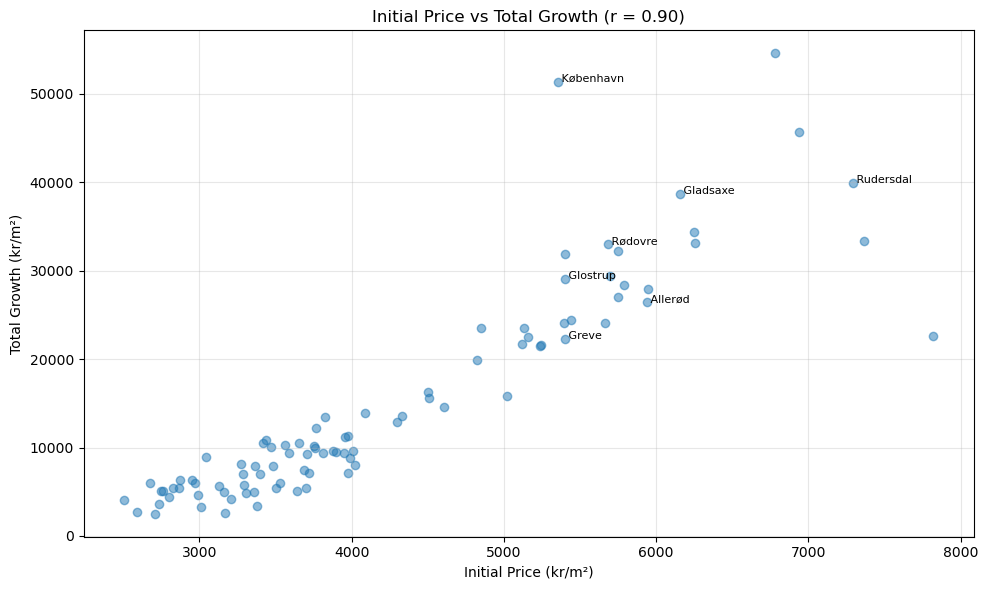

In [15]:
analyzer.plot_growth_vs_initial();

In [16]:
# Calculate correlation manually to show the calculation
quarters = [col for col in muni_data.columns if col != 'Municipality']
initial_prices = muni_data[quarters[0]]
final_prices = muni_data[quarters[-1]]
growth = final_prices - initial_prices

correlation = np.corrcoef(initial_prices, growth)[0, 1]
print(f"Correlation between initial price and growth: {correlation:.3f}")

if correlation > 0:
    print("Positive correlation: Expensive areas grew faster (divergence)")
else:
    print("Negative correlation: Cheaper areas caught up (convergence)")

Correlation between initial price and growth: 0.901
Positive correlation: Expensive areas grew faster (divergence)


The correlation coefficient reveals the relationship between initial price levels and subsequent growth. A positive correlation would suggest that expensive areas have become even more expensive (divergence), while a negative correlation would indicate convergence. The scatter pattern shows whether expensive municipalities in wealthy areas have experienced disproportionate growth, or whether cheaper areas have been catching up.

### Question 1.4

In [17]:
rolling = analyzer.calculate_rolling_average(window=4)

In [18]:
# Show example of rolling average for first municipality
print("Rolling average (4-quarter) for first municipality:")
print(f"Municipality: {rolling['Municipality'].iloc[0]}")
print(f"\nFirst 8 quarters of rolling averages:")
print(rolling.iloc[0, 1:9].values)

Rolling average (4-quarter) for first municipality:
Municipality: København

First 8 quarters of rolling averages:
[np.float64(nan) np.float64(nan) np.float64(nan) np.float64(5337.75)
 np.float64(5266.0) np.float64(5199.75) np.float64(5258.5)
 np.float64(5345.5)]


We calculate a 4-quarter backward rolling average to smooth out short-term fluctuations and identify longer-term trends. The plot below shows this for a sample of 8 municipalities to maintain readability.


Municipalities below pre-crisis peak: 16/92

Still below peak:
  - Gribskov
  - Halsnæs
  - Faxe
  - Guldborgsund
  - Kalundborg
  - Lolland
  - Næstved
  - Odsherred
  - Slagelse
  - Stevns
  - Vordingborg
  - Langeland
  - Haderslev
  - Hedensted
  - Norddjurs
  - Struer


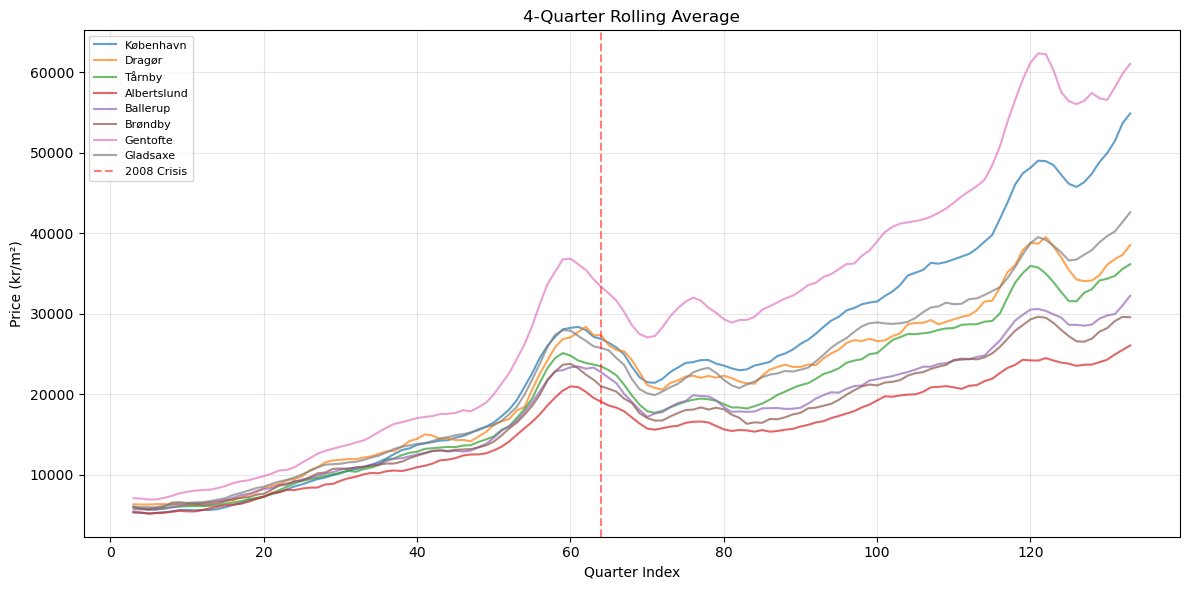

In [19]:
analyzer.analyze_crisis_recovery();

In [20]:
# Calculate recovery statistics
quarters = [col for col in rolling.columns if col != 'Municipality']

# Find approximate 2008Q1 (60% through the data as approximation)
crisis_idx = int(len(quarters) * 0.6)

# Get pre-crisis peaks and current levels
pre_crisis_peaks = rolling[quarters[:crisis_idx]].max(axis=1)
current_levels = rolling[quarters[-1]]

# Identify municipalities below peak
still_below = rolling['Municipality'][current_levels < pre_crisis_peaks]
recovered = rolling['Municipality'][current_levels >= pre_crisis_peaks]

print(f"Crisis recovery analysis:")
print(f"  Recovered: {len(recovered)} municipalities ({len(recovered)/len(rolling)*100:.1f}%)")
print(f"  Still below peak: {len(still_below)} municipalities ({len(still_below)/len(rolling)*100:.1f}%)")

Crisis recovery analysis:
  Recovered: 68 municipalities (73.9%)
  Still below peak: 24 municipalities (26.1%)


## Conclusion

This analysis of Danish house prices from 1992 onwards reveals several key findings:

1. Geographic Divergence: House prices have grown substantially more in urban centers, particularly Copenhagen, compared to peripheral regions. This reflects broader economic trends of centralization and urbanization in Denmark.

2. Inflation Impact: Real price growth is considerably lower than nominal growth, emphasizing the importance of inflation adjustment when evaluating housing as an investment. Housing has not universally served as a strong inflation hedge.

3. Crisis Legacy: The 2008 financial crisis had a profound and lasting impact. Many municipalities have still not recovered to their pre-crisis peak levels, creating significant wealth disparities across regions.

4. Policy Implications: The persistent divergence between urban and peripheral areas raises important questions about regional inequality, mobility, and the need for place-based economic policies to support struggling housing markets.

These patterns have important implications for homeowners, policymakers, and researchers studying wealth inequality and regional economic development in Denmark.

The rolling average reveals the persistence of the crisis impact. Municipalities that remain below their pre-2008 peaks are experiencing a "lost decade" in terms of housing wealth. This has significant implications for homeowners' wealth, mobility, and the local economy in these areas. The divergence between recovering and non-recovering municipalities highlights the uneven geographic impact of the financial crisis.

## 2. Exchange economy 

In [21]:
# Initialize exchange economy model
model = ExchangeEconomyModelClass()
par = model.par

print("EXCHANGE ECONOMY ANALYSIS")
print(f"\nModel Parameters:")
print(f"  alpha_A = {par.alpha_A}, beta_A = {par.beta_A}, rho_A = {par.rho_A}")
print(f"  alpha_B = {par.alpha_B}, beta_B = {par.beta_B}, rho_B = {par.rho_B}")
print(f"  w1A = {par.w1A}, w2A = {par.w2A}")
print(f"  w1B = {1-par.w1A}, w2B = {1-par.w2A}")

EXCHANGE ECONOMY ANALYSIS

Model Parameters:
  alpha_A = 1.0, beta_A = 0.034114465085977146, rho_A = -2.0
  alpha_B = 0.034114465085977146, beta_B = 1.0, rho_B = -2.0
  w1A = 0.99999999, w2A = 1e-08
  w1B = 1.0000000050247593e-08, w2B = 0.99999999


### Question 2.1

2.1: Excess Demand Analysis

Equilibria found: 3
  p1* = 0.4212
  p1* = 0.9965
  p1* = 2.3659


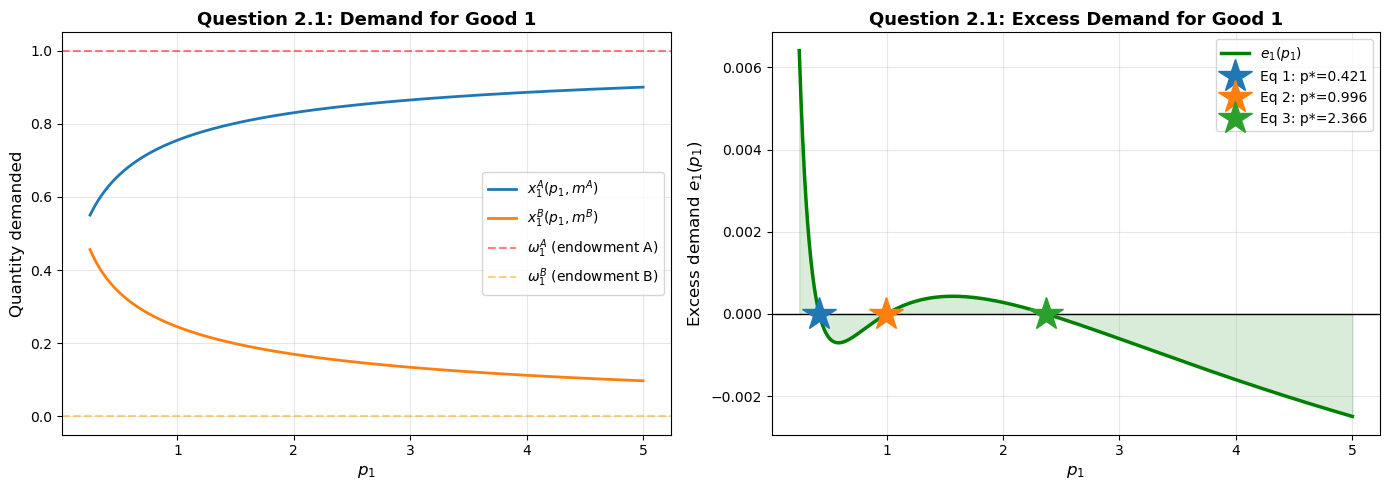

In [22]:
# Create demand and excess demand data
p1_grid = np.linspace(0.25, 5, 1000)
x1A_vec = np.zeros_like(p1_grid)
x1B_vec = np.zeros_like(p1_grid)
e1_vec = np.zeros_like(p1_grid)

for i, p1 in enumerate(p1_grid):
    x1A, _ = model.demand_A(p1)
    x1B, _ = model.demand_B(p1)
    x1A_vec[i] = x1A
    x1B_vec[i] = x1B
    e1_vec[i] = (x1A - par.w1A) + (x1B - (1-par.w1A))

# Find equilibria by looking for sign changes
sign_changes = np.where(np.diff(np.sign(e1_vec)))[0]
equilibrium_prices_true = p1_grid[sign_changes]

print("2.1: Excess Demand Analysis\n")
print(f"Equilibria found: {len(equilibrium_prices_true)}")
for i, p in enumerate(equilibrium_prices_true):
    print(f"  p1* = {p:.4f}")

# Plot demand and excess demand
plot_demand_and_excess_demand(p1_grid, x1A_vec, x1B_vec, e1_vec, par, equilibrium_prices_true)

This model has three equilibria as you can see in the right plot. This is because of the extreme endowments the consumers have:


Consumer A owns nearly 100% of good 1, and almost none of good 2


Consumer B owns essentially 0% of good 1, nearly 100% of good 2

This creates a non-monotonic excess demand function with three equilibrium prices:

1. p₁* ≈ 0.42: At this low price, good 1 is cheap. Consumer A demands less of it while Consumer B, endowed with good 2, demands a lot of the cheap good 1. Overall excess demand for good 1 is negative → pressure for higher prices.

2. p₁* ≈ 1.00: This is the middle equilibrium where prices balance supply and demand at roughly equal terms.

3. p₁* ≈ 2.37: At this high price, good 1 is expensive. Consumer A demands more of it while Consumer B cannot afford much of the expensive good 1. Overall excess demand for good 1 becomes positive → pressure for lower prices.

### Question 2.2

The tâtonnement mechanism is a dynamic process where prices are adjusted based on excess demand. When there is positive excess demand (e₁ > 0), more people want to buy than sell, so the price is too low and gets raised. When there is negative excess demand (e₁ < 0), more people want to sell than buy, so the price is too high and gets lowered. The process continues until zero excess demand is reached (e₁ = 0), where supply equals demand and the market clears.

In [23]:
# Run for three initial guesses
print("\n2.2: Tâtonnement Algorithm")
print(f"Initial guess p1⁰ = 0.9:")
p1_star_09, history_09 = tatonnement(model, 0.9, tau=1e-8, nu=50, K=5000, verbose=False)
print(f"  Converged to p1* = {p1_star_09:.6f}")

print(f"\nInitial guess p1⁰ = 1.0:")
p1_star_099, history_099 = tatonnement(model, 1.0, tau=1e-8, nu=50, K=5000, verbose=False)
print(f"  Converged to p1* = {p1_star_099:.6f}")

print(f"\nInitial guess p1⁰ = 1.1:")
p1_star_11, history_11 = tatonnement(model, 1.1, tau=1e-8, nu=50, K=5000, verbose=False)
print(f"  Converged to p1* = {p1_star_11:.6f}")


2.2: Tâtonnement Algorithm
Initial guess p1⁰ = 0.9:
  Converged to p1* = 0.421876

Initial guess p1⁰ = 1.0:
  Converged to p1* = 1.000000

Initial guess p1⁰ = 1.1:
  Converged to p1* = 2.370356


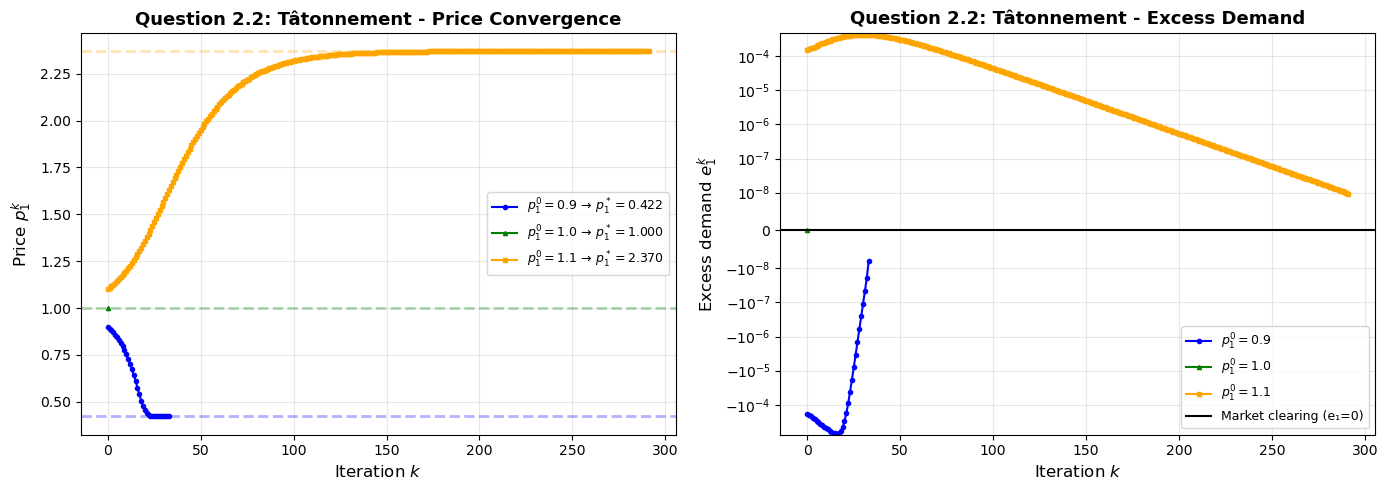

In [24]:
# Plot convergence
histories = [history_09, history_099, history_11]
p1_stars = [p1_star_09, p1_star_099, p1_star_11]
labels = ['0.9', '1.0', '1.1']
plot_tatonnement_convergence(histories, p1_stars, labels)

The three initial guesses demonstrate how the choice of starting point determines which equilibrium is found. Starting at p₁⁰ = 0.9 converges to the lower equilibrium at p₁* ≈ 0.42, while p₁⁰ = 1.0 converges to the middle equilibrium at p₁* ≈ 1.00, and p₁⁰ = 1.1 converges to the upper equilibrium at p₁* ≈ 2.37.

This reveals important stability properties. The middle equilibrium (p₁* ≈ 1.00) is stable under tâtonnement—when we start exactly at it, the algorithm stays there. However, its basin of attraction is extremely narrow with this large step size (ν = 50). Starting even slightly away causes convergence to the outer equilibria instead.

The outer equilibria (p₁* ≈ 0.42 and p₁* ≈ 2.37) are theoretically unstable, but with large step sizes, they have wide basins of attraction and are practically much easier to reach. The choice of initial guess therefore determines which equilibrium is found, and the stability of an equilibrium depends on both its mathematical properties and practical factors like the step size used.

## 2.3: Global Convergence Behavior

When we test tâtonnement from a range of 50 different initial prices spanning 0.25 to 5.5, we find that the algorithm discovers different equilibriums depending on the starting point. This demonstrates the basin of attraction for each equilibrium:

- Initial prices below the middle equilibrium tend to converge to the low equilibrium
- Initial prices above the middle equilibrium tend to converge to the high equilibrium

The stable middle equilibrium, despite its theoretical stability, has a small basin of attraction with this step size, making it practically harder to reach from far away.

In [25]:
# Apply tâtonnement for a range of initial prices
p1_init_grid = np.linspace(0.25, 5, 50)
p1_final = np.zeros_like(p1_init_grid)

print("\n2.3: Tâtonnement - Global Behavior")

for i, p1_0 in enumerate(p1_init_grid):
    p1_star, _ = tatonnement(model, p1_0, tau=1e-8, nu=50, K=5000, verbose=False)
    p1_final[i] = p1_star

# Find unique equilibria
unique_equilibria = find_unique_equilibria(p1_final)

print(f"Unique equilibria found: {len(unique_equilibria)}")
for eq in sorted(unique_equilibria):
    print(f"  p1* = {eq:.6f}")


2.3: Tâtonnement - Global Behavior
Unique equilibria found: 2
  p1* = 0.421876
  p1* = 2.370356


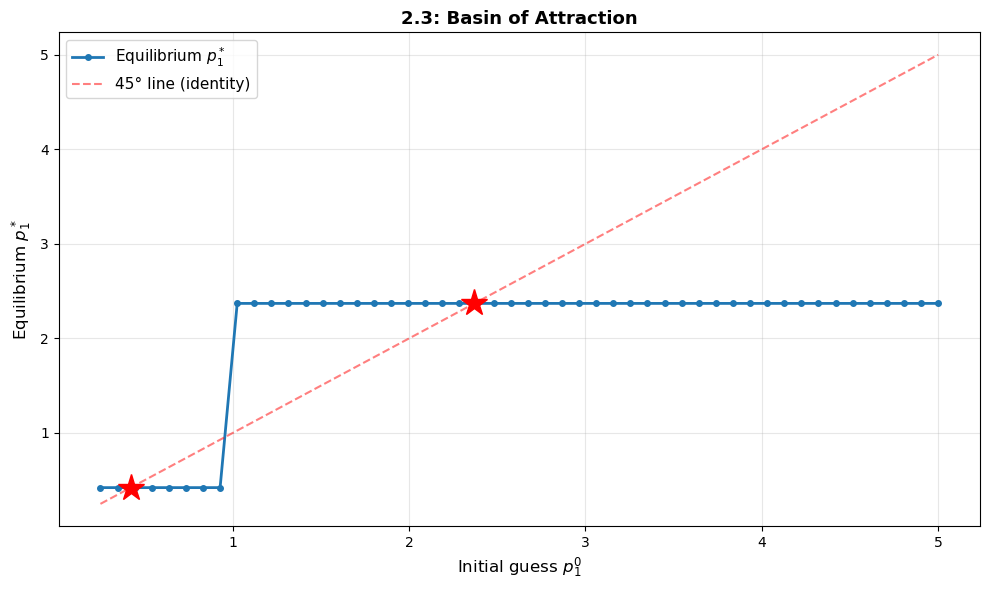

In [26]:
# Plot basin of attraction
plot_basin_of_attraction(p1_init_grid, p1_final, unique_equilibria, '2.3: Basin of Attraction')

The tâtonnement algorithm only finds two equilibriums. Either the low equilibrium (p₁* ≈ 0.42) or the high equilibrium (p₁* ≈ 2.37) depending on the initial guess, but not the stable middle equilibrium (p₁* ≈ 1.0). This demonstrates that the stable equilibrium has a small basin of attraction with this step size—the middle equilibrium is stable but hard to reach from far away.

### Question 2.4

The Newton-Raphson method uses slope information to decide both the direction and size of each step - instead of always moving the same amount like tâtonnement, it adjusts how far to jump based on how steep the excess demand curve is. The price update formula is:

$$p_1^{k+1} = p_1^k - \varphi \frac{e_1^k}{\Delta}$$

where $\Delta = \frac{e_1(p_1^k + h) - e_1^k}{h}$ is the slope of excess demand, $\varphi = 0.1$ is a control parameter (prevents jumping too far), and $\iota = 0.99$ keeps prices positive.

We test this method with 50 different starting prices from np.linspace(0.25, 5, 50) to see which equilibria we reach.

In [27]:
# Apply Newton-Raphson for a range of initial prices
p1_init_grid_nr = np.linspace(0.25, 5, 50)
p1_final_nr = np.zeros_like(p1_init_grid_nr)

print("\n2.4: Dampened Newton-Raphson Algorithm")

for i, p1_0 in enumerate(p1_init_grid_nr):
    p1_star, _ = newton_raphson_dampened(model, p1_0, tau=1e-8, varphi=0.1, iota=0.99, K=5000, verbose=False)
    p1_final_nr[i] = p1_star

# Find unique equilibria using imported function
unique_equilibria_nr = find_unique_equilibria(p1_final_nr)

print(f"Unique equilibria found: {len(unique_equilibria_nr)}")
for eq in sorted(unique_equilibria_nr):
    print(f"  p1* = {eq:.6f}")


2.4: Dampened Newton-Raphson Algorithm
Unique equilibria found: 3
  p1* = 0.421875
  p1* = 0.999995
  p1* = 2.370356


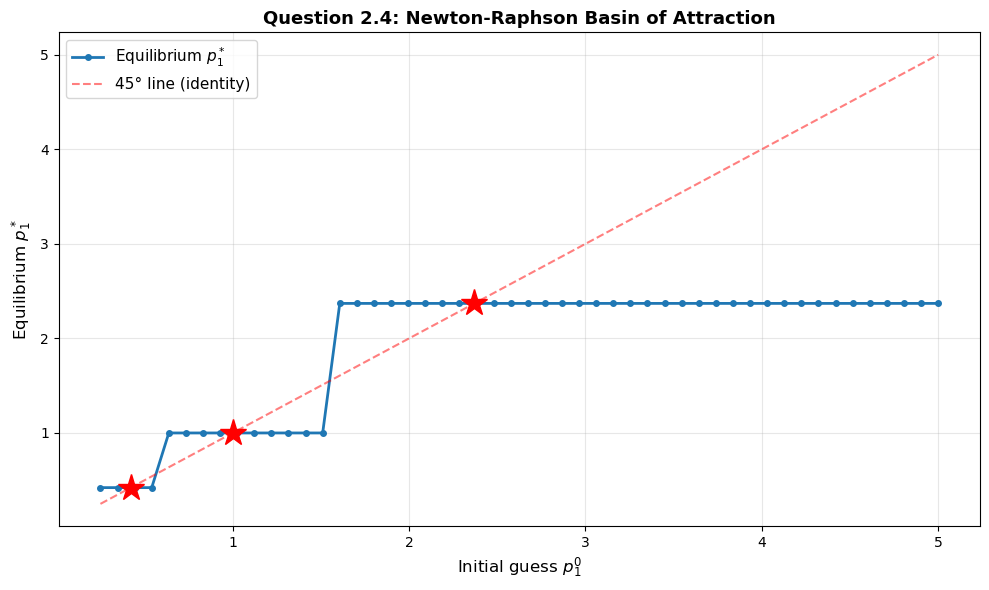

In [28]:
# Plot basin of attraction
plot_basin_of_attraction(p1_init_grid_nr, p1_final_nr, unique_equilibria_nr, 'Question 2.4: Newton-Raphson Basin of Attraction')

the dampened Newton-Raphson algorithm does find all three equilibria! 
This is better than tâtonnement, which only found 2 equilibria (low and high) and missed the stable middle equilibrium at p₁⁰ = 1.0. instead of always moving the same amount like tâtonnement, it adjusts how far to jump based on how steep the excess demand curve is. Newton-Raphson successfully finds the middle equilibrium because the derivative-based adjustment and dampening factor (φ = 0.1) help it converge from a wider range of starting points. 

### Question 2.5

In [29]:
# Find all three equilibrium prices (from Q2.1)
equilibrium_prices = [0.4219, 1.0000, 2.3704]  # Low, middle, high equilibria

print("\n2.5: Edgeworth Box - All Equilibria")
print(f"\nFound {len(equilibrium_prices)} equilibria:\n")

# Calculate allocations for all equilibria
allocations = []
for i, p1_eq in enumerate(equilibrium_prices):
    x1A, x2A = model.demand_A(p1_eq)
    x1B, x2B = model.demand_B(p1_eq)
    allocations.append({'p1': p1_eq, 'x1A': x1A, 'x2A': x2A, 'x1B': x1B, 'x2B': x2B})
    print(f"Equilibrium {i+1}: p1* = {p1_eq:.4f}")
    print(f"  Consumer A: x1A = {x1A:.4f}, x2A = {x2A:.4f}")
    print(f"  Consumer B: x1B = {x1B:.4f}, x2B = {x2B:.4f}")
    print(f"  Market clearing: x1A + x1B = {x1A + x1B:.4f}, x2A + x2B = {x2A + x2B:.4f}\n")


2.5: Edgeworth Box - All Equilibria

Found 3 equilibria:

Equilibrium 1: p1* = 0.4219
  Consumer A: x1A = 0.6343, x2A = 0.1543
  Consumer B: x1B = 0.3657, x2B = 0.8457
  Market clearing: x1A + x1B = 1.0000, x2A + x2B = 1.0000

Equilibrium 2: p1* = 1.0000
  Consumer A: x1A = 0.7551, x2A = 0.2449
  Consumer B: x1B = 0.2449, x2B = 0.7551
  Market clearing: x1A + x1B = 1.0000, x2A + x2B = 1.0000

Equilibrium 3: p1* = 2.3704
  Consumer A: x1A = 0.8457, x2A = 0.3657
  Consumer B: x1B = 0.1543, x2B = 0.6343
  Market clearing: x1A + x1B = 1.0000, x2A + x2B = 1.0000



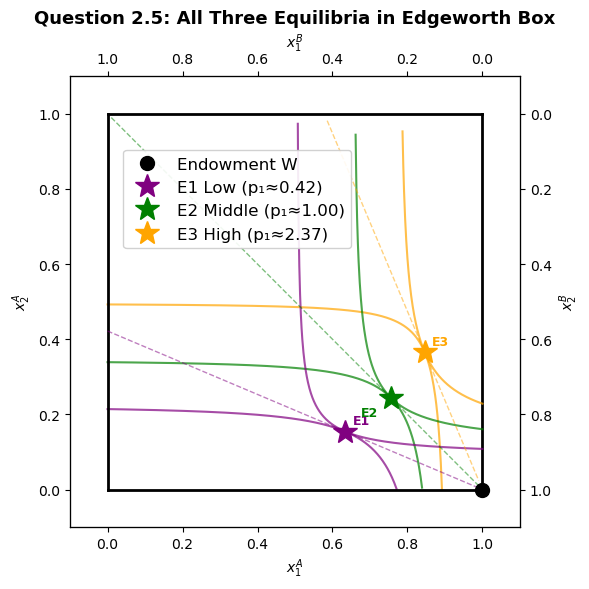

In [30]:
# Plot Edgeworth box
colors = ['purple', 'green', 'orange']
equilibrium_labels = ['Low (p₁≈0.42)', 'Middle (p₁≈1.00)', 'High (p₁≈2.37)']
plot_edgeworth_box_equilibria(model, par, allocations, equilibrium_labels, colors)

The Edgeworth box visualizes all three Walras equilibria at different price ratios: low (p₁* ≈ 0.42), middle (p₁* ≈ 1.00), and high (p₁* ≈ 2.37). All three satisfy the tangency condition (MRSᴬ = MRSᴮ = p₁), market clearing, and are Pareto efficient. This demonstrates that the exchange economy has multiple Pareto-efficient allocations corresponding to different price ratios.

### Conclusion

This analysis of an exchange economy with extreme endowments reveals that the model has three distinct Walrasian equilibria at prices p₁* ≈ 0.42, 1.00, and 2.37. The existence of multiple equilibria arises from the non-monotonic excess demand function, which crosses zero three times due to the asymmetric initial endowments where Consumer A owns almost all of good 1 and Consumer B owns nearly all of good 2.

The tâtonnement algorithm successfully converges to equilibria, but its behavior depends critically on the initial price guess. When starting at p₁⁰ = 0.9, 1.0, or 1.1, the algorithm finds different equilibria, demonstrating path dependence. Testing across 50 different starting points revealed that tâtonnement only finds two of the three equilibria (the low and high price equilibria), missing the middle equilibrium at p₁* ≈ 1.00 despite it being theoretically stable. This occurs because the middle equilibrium has an extremely narrow basin of attraction with the large step size (ν = 50) used.

The dampened Newton-Raphson method on the other hand proves superior both because it converges significantly faster and especially because it finds all three equilibria The derivative-based adjustment and dampening factor allow the algorithm to successfully reach the middle equilibrium from a wider range of starting points.   

# 3. The AS-AD Model

We are using the file ASADModel.py which was imported in the top of the notebook

### Question 3.1

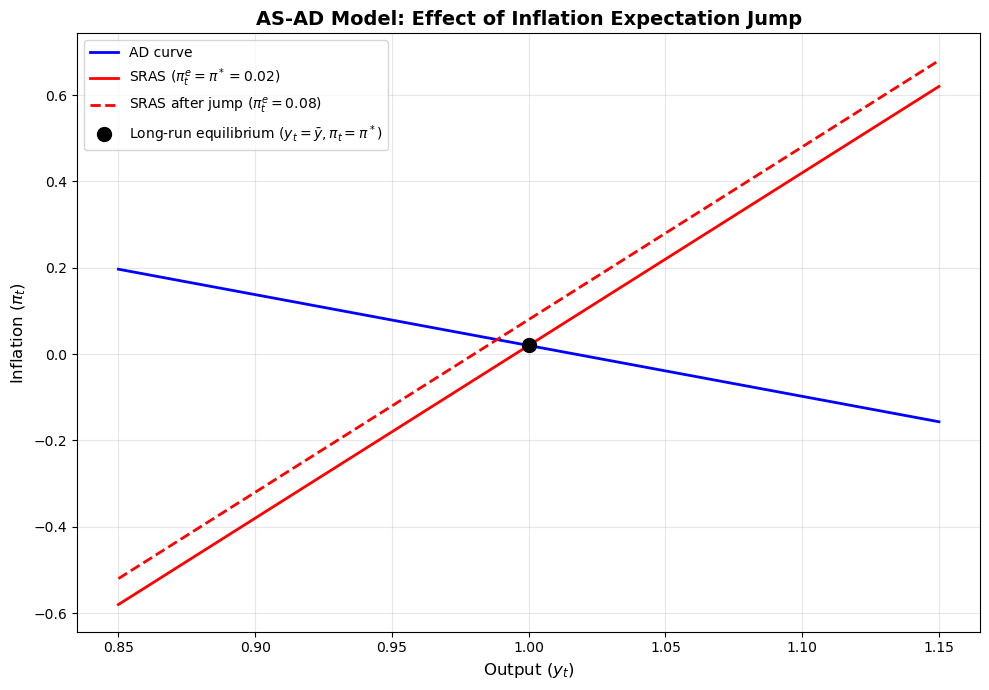

Long-run equilibrium: y = 1.0, π = 0.02
When π^e_t jumps from 0.02 to 0.08, the SRAS curve shifts upward by 0.06


In [31]:
model = ASADModelClass()

# Plot the effect of inflation expectation jump using method from py file
model.plot_expectation_jump(pi_e_initial=0.02, pi_e_jumped=0.08)


The SRAS curve is defined by equation (9), here we can se that higher expected inflation makes this move up. That happends because workers want a higher wage if they expect the prices to jump up, and the firms want higher prices immediately if the prices is expected to rise. However if this is only a temorary shock, the long run equilibrium is expected to stay put, and the SRAS curve will eventually get back to its original spot. Because expected inflation has an effect on actual inflation, it is important to try to keep the inflation expectations down, as this will effect actual inflation.

### Question 3.2

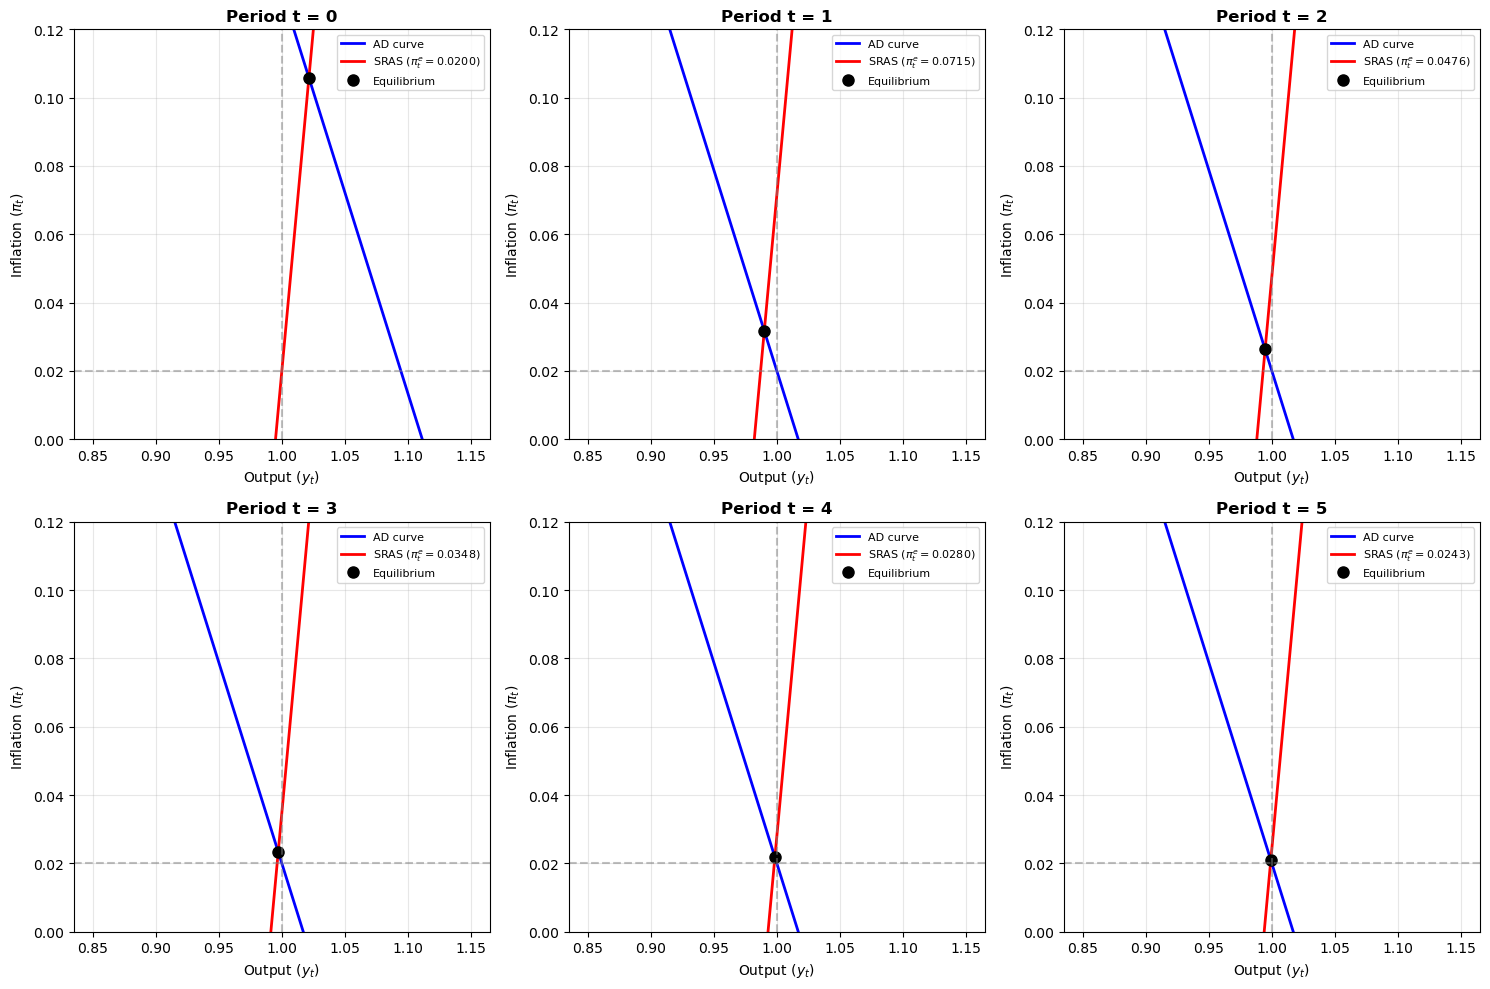

Simulation Results:
t    π^e_t       v_t       y*_t        π*_t        
0    0.0200      0.10      1.0215      0.1058      
1    0.0715      0.00      0.9901      0.0317      
2    0.0476      0.00      0.9947      0.0263      
3    0.0348      0.00      0.9971      0.0234      
4    0.0280      0.00      0.9985      0.0218      
5    0.0243      0.00      0.9992      0.0210      


In [32]:
# Get parameters from model
p = model.par

# Simulation parameters
T = 5  
phi = p['phi'] 

# Initialize arrays
pi_e = np.zeros(T + 1)
y_star = np.zeros(T + 1)
pi_star_sim = np.zeros(T + 1)

# Initial conditions
pi_e[0] = p['pi_star'] 
v = np.zeros(T + 1)
v[0] = 0.1  

# Simulate forward
for t in range(T + 1):
    y_star[t], pi_star_sim[t] = model.equilibrium(pi_e[t], v[t])
    
    if t < T:
        pi_e[t + 1] = phi * pi_star_sim[t] + (1 - phi) * pi_e[t]

# Plot period-by-period dynamics using py file
model.plot_period_dynamics(pi_e, v, y_star, pi_star_sim)

# Print results
print("Simulation Results:")
print(f"{'t':<5}{'π^e_t':<12}{'v_t':<10}{'y*_t':<12}{'π*_t':<12}")
for t in range(T + 1):
    print(f"{t:<5}{pi_e[t]:<12.4f}{v[t]:<10.2f}{y_star[t]:<12.4f}{pi_star_sim[t]:<12.4f}")

When t=0, we can see the expected inflation to be = 0,02, but since the shock hits, the actual inflation π* = 0,1058 due to the demand shock (v_t = 0,10). This also makes output go higher, as more goods are now wanted, and more good are therefore produced. The expected inflation for the next period is now higher as this shock still affects the expectations. This leads to a lower output leading to a lower actual inflation (expected inflation has a negative effect on output as given in equation 10). The effect from the shock is watered the more periods you go away from the shock, this i why the actual inflation is almost back at 2% as it was before the shock happend. If we had let the simulation go on for longer periods we would've seen the actual infaltion go back to 2% (as shown beneath)

In [33]:
# Extended simulation to show inflation will go back to 2%
T_extended = 10  
pi_e_ext = np.zeros(T_extended + 1)
y_star_ext = np.zeros(T_extended + 1)
pi_star_ext = np.zeros(T_extended + 1)
v_ext = np.zeros(T_extended + 1)

# Initial conditions
pi_e_ext[0] = p['pi_star'] 
v_ext[0] = 0.1  

# Simulate forward
for t in range(T_extended + 1):
    y_star_ext[t], pi_star_ext[t] = model.equilibrium(pi_e_ext[t], v_ext[t])
    
    if t < T_extended:
        pi_e_ext[t + 1] = phi * pi_star_ext[t] + (1 - phi) * pi_e_ext[t]

# Show only periods 6-10 to demonstrate convergence to 2%
print("\nExtended Simulation (t = 6 to 10):")
print(f"{'t':<5}{'π^e_t':<12}{'v_t':<10}{'y*_t':<12}{'π*_t':<12}")
for t in range(6, T_extended + 1):
    print(f"{t:<5}{pi_e_ext[t]:<12.4f}{v_ext[t]:<10.2f}{y_star_ext[t]:<12.4f}{pi_star_ext[t]:<12.4f}")


Extended Simulation (t = 6 to 10):
t    π^e_t       v_t       y*_t        π*_t        
6    0.0223      0.00      0.9996      0.0205      
7    0.0212      0.00      0.9998      0.0203      
8    0.0207      0.00      0.9999      0.0201      
9    0.0204      0.00      0.9999      0.0201      
10   0.0202      0.00      1.0000      0.0200      


### Question 3.3

In [34]:
# Setup simulation with parameters and seed  
T = 500
rho_values = [0.8, 0.5]
sigma_e = 0.01
np.random.seed(123)

# Generate random shocks
epsilon = np.random.normal(0, sigma_e, T)

# Run simulations for both rho values
results = {}

for rho in rho_values:
    results[rho] = model.simulate(rho, epsilon)


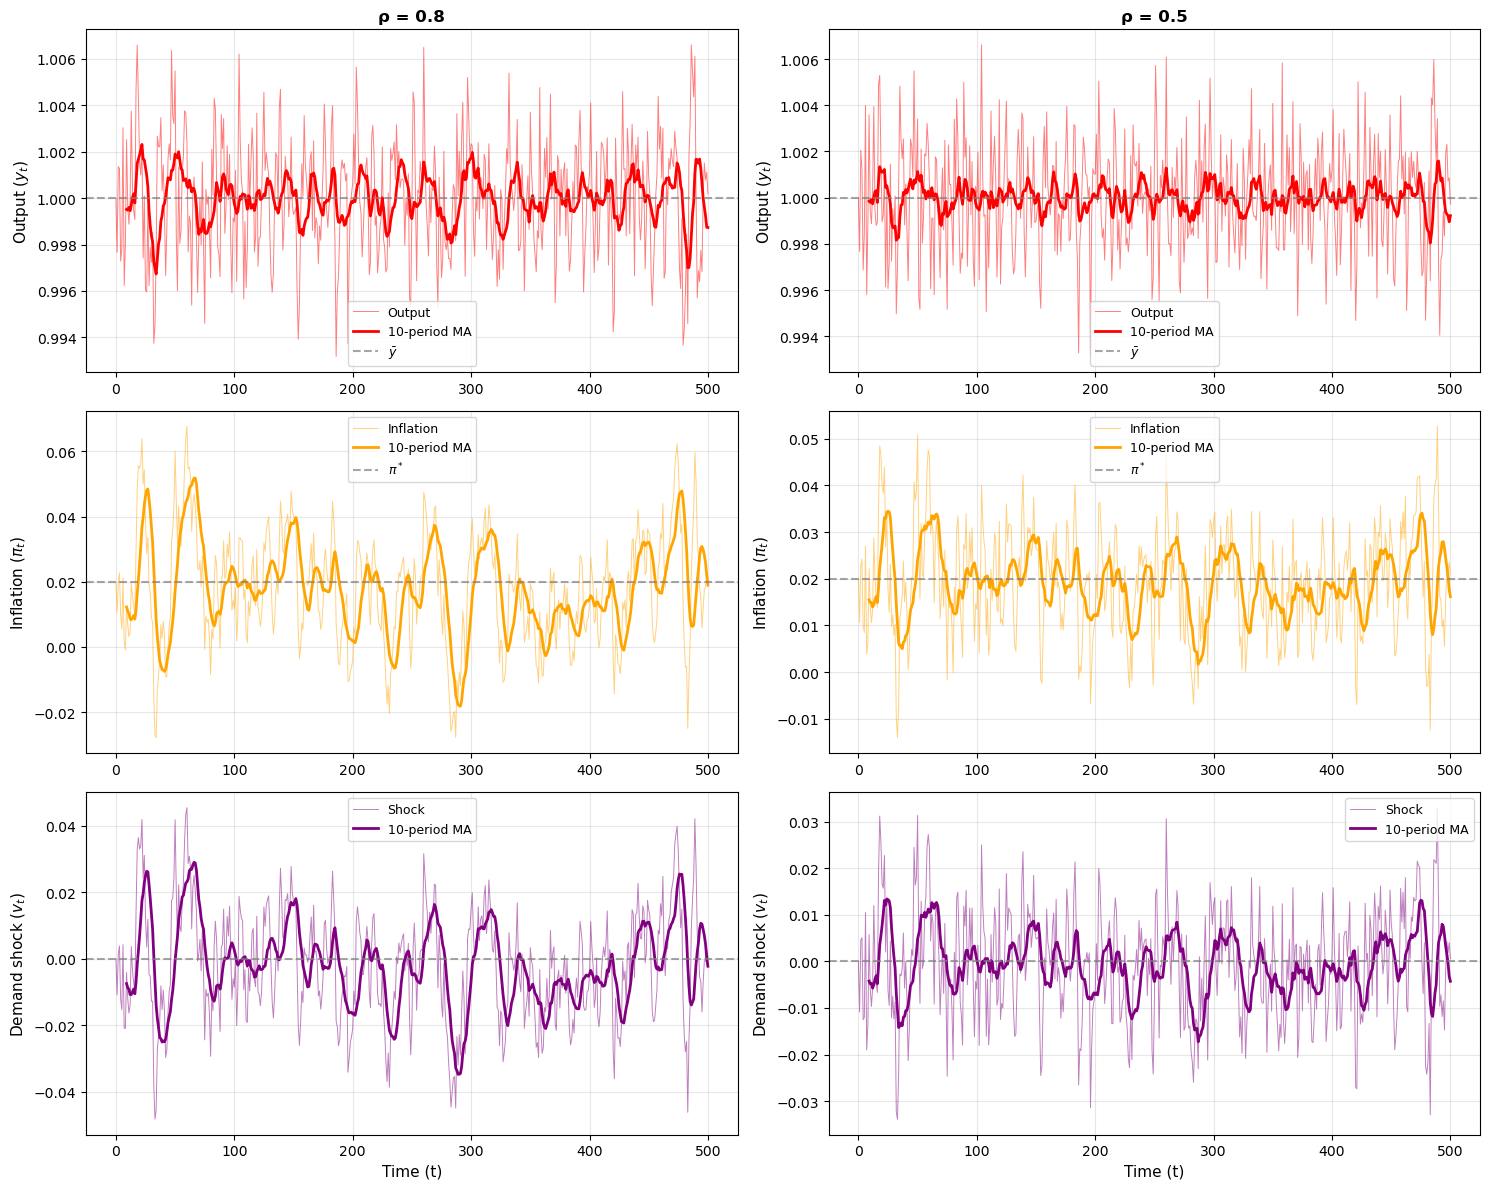

In [35]:
# Plot time series for both scenarios from py file
model.plot_simulation_results(results, rho_values, window=10)

Its clear to see that the shock is not nearly as big on average when ρ = 0,5. This makes sense as the ρ parameter decides how much of the shock is transfered to the next period. 

In [36]:
# Compute statistics using the models moments method
for rho in rho_values:
    y = results[rho]['y']
    pi = results[rho]['pi']
    
    # Use the moments method from pyfile
    stats = model.moments(y, pi)
    
    print(f"\nρ = {rho}:")
    print(f"Standard deviation of output gap: {stats['sd_y_gap']:.6f}")
    print(f"Standard deviation of inflation:  {stats['sd_pi']:.6f}")
    print(f"Correlation (y_gap, π):           {stats['corr']:.6f}")


ρ = 0.8:
Standard deviation of output gap: 0.002476
Standard deviation of inflation:  0.017263
Correlation (y_gap, π):           0.401556

ρ = 0.5:
Standard deviation of output gap: 0.002355
Standard deviation of inflation:  0.011224
Correlation (y_gap, π):           0.587516


Here we can also see that the ρ value plays a part, as the deviation is lower meaning the economy is more stable with a lover ρ value. This means the inflation and output gap, doesn't change as much when the ρ value is 0,5.